In [1]:
import numpy as np

In [2]:
# (1, 2) (2, 3)
means = np.array([10, 10])

In [3]:
nums = np.array([[1, 2], [1, 2]])

In [4]:
nums - means

array([[-9, -8],
       [-9, -8]])

In [5]:
np.argmax([1, 2, 3, 4, 5])

np.int64(4)

In [6]:
x_grid = np.linspace(0, 1, 101).reshape(-1, 1)

In [14]:
x_grid

array([[0.  ],
       [0.01],
       [0.02],
       [0.03],
       [0.04],
       [0.05],
       [0.06],
       [0.07],
       [0.08],
       [0.09],
       [0.1 ],
       [0.11],
       [0.12],
       [0.13],
       [0.14],
       [0.15],
       [0.16],
       [0.17],
       [0.18],
       [0.19],
       [0.2 ],
       [0.21],
       [0.22],
       [0.23],
       [0.24],
       [0.25],
       [0.26],
       [0.27],
       [0.28],
       [0.29],
       [0.3 ],
       [0.31],
       [0.32],
       [0.33],
       [0.34],
       [0.35],
       [0.36],
       [0.37],
       [0.38],
       [0.39],
       [0.4 ],
       [0.41],
       [0.42],
       [0.43],
       [0.44],
       [0.45],
       [0.46],
       [0.47],
       [0.48],
       [0.49],
       [0.5 ],
       [0.51],
       [0.52],
       [0.53],
       [0.54],
       [0.55],
       [0.56],
       [0.57],
       [0.58],
       [0.59],
       [0.6 ],
       [0.61],
       [0.62],
       [0.63],
       [0.64],
       [0.65],
       [0.

In [11]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

real_noise_std = 1e-10
noise_assumption = 1e-10

rbf_lengthscale = 0.1

#Acquisition function parameter
beta = 1.96

#Draw random function parameters
modes = np.random.randint(1, 5)
std = np.random.uniform(low = 0.005, high = 0.05, size = modes)
means = np.random.uniform(size = modes)
amps = np.random.uniform(size = modes) * (2 - 1) + 1

#Define function
def calc_function(x):
  exp = -(x - means) ** 2 / std
  y = amps * np.exp(exp)
  return np.sum(y)

#Define kernel of GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)

In [12]:
post_mean, post_std = model.predict(x_grid, return_std=True)

In [15]:
post_std

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

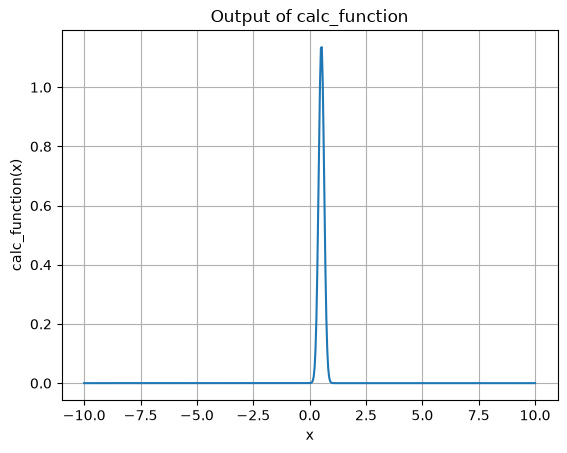

In [16]:
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(-10, 10, 500)
ys = np.array([calc_function(x) for x in xs])

plt.plot(xs, ys)
plt.xlabel("x")
plt.ylabel("calc_function(x)")
plt.title("Output of calc_function")
plt.grid(True)
plt.show()

In [17]:
def euler_approximation(n):
    return (1 + 1/n) ** n

# Test increasing values of n
n_values = [1, 10, 100, 1_000, 10_000, 100_000, 1_000_000, 10_000_000, 100_000_000]

print(f"{'n':>15} | {'(1 + 1/n)^n':>15} | {'Error vs true e':>15}")
print("-" * 50)

import math
true_e = math.e

for n in n_values:
    approx = euler_approximation(n)
    error = abs(approx - true_e)
    print(f"{n:>15,} | {approx:>15.10f} | {error:>15.2e}")

print(f"\nTrue value of e (math.e): {true_e:.10f}")

              n |     (1 + 1/n)^n | Error vs true e
--------------------------------------------------
              1 |    2.0000000000 |        7.18e-01
             10 |    2.5937424601 |        1.25e-01
            100 |    2.7048138294 |        1.35e-02
          1,000 |    2.7169239322 |        1.36e-03
         10,000 |    2.7181459268 |        1.36e-04
        100,000 |    2.7182682372 |        1.36e-05
      1,000,000 |    2.7182804691 |        1.36e-06
     10,000,000 |    2.7182816941 |        1.34e-07
    100,000,000 |    2.7182817983 |        3.01e-08

True value of e (math.e): 2.7182818285


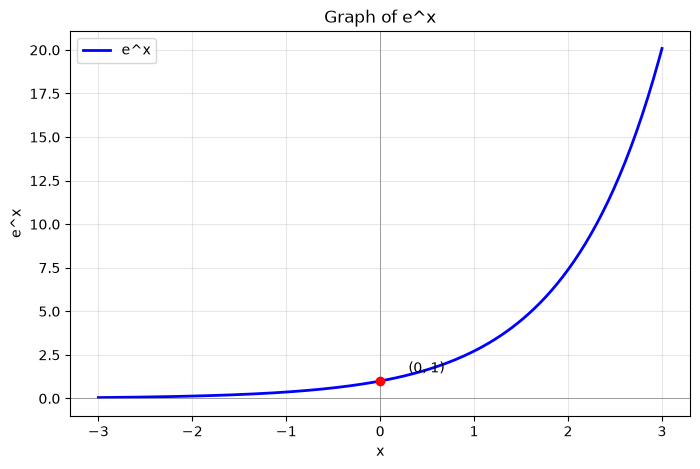

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Generate x values
x = np.linspace(-3, 3, 200)
y = np.exp(x)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, y, label='e^x', color='blue', linewidth=2)
plt.axhline(y=0, color='gray', linewidth=0.5)
plt.axvline(x=0, color='gray', linewidth=0.5)
plt.scatter([0], [1], color='red', zorder=5)  # mark (0, 1)
plt.annotate('(0, 1)', xy=(0, 1), xytext=(0.3, 1.5))

plt.title("Graph of e^x")
plt.xlabel("x")
plt.ylabel("e^x")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
def calc_function(x):
  exp = -(x - means) ** 2 / std
  y = amps * np.exp(exp)
  return np.sum(y)

In [20]:
x = np.linspace(-3, 3, 200)
y = np.array([calc_function(xi) for xi in x])

Text(0.5, 0, 'x')

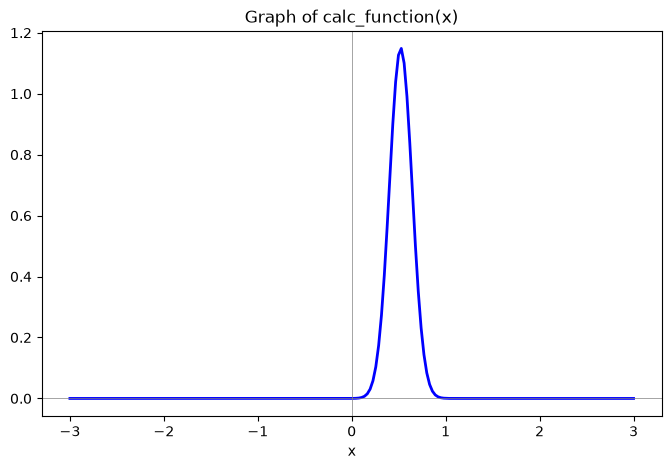

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(x, y, label='calc_function(x)', color='blue', linewidth=2)
plt.axhline(y=0, color='gray', linewidth=0.5)
plt.axvline(x=0, color='gray', linewidth=0.5)
plt.title("Graph of calc_function(x)")
plt.xlabel("x")

In [22]:
means

array([0.52191974])

In [23]:
calc_function(0)

np.float64(0.0001063123258483359)

In [24]:
(-0 - means) ** 2 / std

array([9.28867962])

In [25]:
np.exp(-(-0 - means) ** 2 / std)

array([9.24650685e-05])

In [26]:
amps * np.exp(-(-0 - means) ** 2 / std)

array([0.00010631])

In [30]:
math.log((amps * np.exp(-(-0 - means) ** 2 / std)))

TypeError: only 0-dimensional arrays can be converted to Python scalars

In [33]:
x1_ = [1, 2, 3]
x2_ = [4, 5, 6]

for x1_, x2_ in zip(x1_, x2_):
    print(f"x1_: {x1_}, x2_: {x2_}")

x1_: 1, x2_: 4
x1_: 2, x2_: 5
x1_: 3, x2_: 6
